# Model 7 — Dynamic Pricing
**Input:** `retail_store_inventory.csv`  
**Output:** `data_pricing.csv`, `models/pricing_model.pkl`  

**Core idea — 3 features only:**
- `rating` (1–5): how well-received the product is
- `rating_count`: how many customers rated it (proxy for market exposure)
- `price_comp_ratio`: our price / competitor price (are we over or under priced)

**Label logic:**

| Rating | Rating Count | Action |
|---|---|---|
| High (≥4) | High (≥50) | increase — proven demand, room to grow |
| High (≥4) | Low (<50) | discount — good product, build volume |
| Low (≤2) | High (≥50) | decrease — known issue, fix price |
| Low (≤2) | Low (<50) | hold — not enough data yet |
| Mid (2–4) | Any | hold |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

os.makedirs('models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/retail_project/models', exist_ok=True)

DATA_PATH = '/content/drive/MyDrive/retail_project/retail_store_inventory.csv'
# DATA_PATH = 'retail_store_inventory.csv'  # local fallback

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
print(df.shape)
df.head(3)

(73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer


## 1. Feature Engineering — 3 Features

The dataset has no explicit rating column.  
We engineer a realistic `rating` from `fill_rate` (how well units sold vs forecast) + noise.  
`rating_count` is derived from sales volume — high-selling products accumulate more reviews.  
`price_comp_ratio` is the only market context feature: our price / competitor price.

In [4]:
np.random.seed(42)

# fill_rate: how much of demand actually sold (0 to ~1)
fill_rate = df['Units Sold'] / (df['Demand Forecast'] + 1)

# rating 1-5: scale fill_rate + small noise to simulate customer satisfaction
rating_raw = fill_rate * 4 + 1                            # map 0-1 -> 1-5
noise      = np.random.normal(0, 0.3, len(df))
df['rating'] = (rating_raw + noise).clip(1, 5).round(1)

# rating_count: popular products get reviewed more often
df['rating_count'] = (
    df['Units Sold'] * np.random.uniform(0.3, 0.8, len(df))
).astype(int).clip(1, 500)

# price_comp_ratio: >1 means we're more expensive than competitor
df['price_comp_ratio'] = (df['Price'] / (df['Competitor Pricing'] + 0.01)).round(3)

print(df[['rating', 'rating_count', 'price_comp_ratio']].describe().round(3))

          rating  rating_count  price_comp_ratio
count  73100.000     73100.000         73100.000
mean       4.530        74.595             1.008
std        0.727        64.915             0.099
min        1.000         1.000             0.672
25%        4.400        24.000             0.956
50%        4.800        56.000             1.000
75%        5.000       108.000             1.047
max        5.000       389.000             1.988


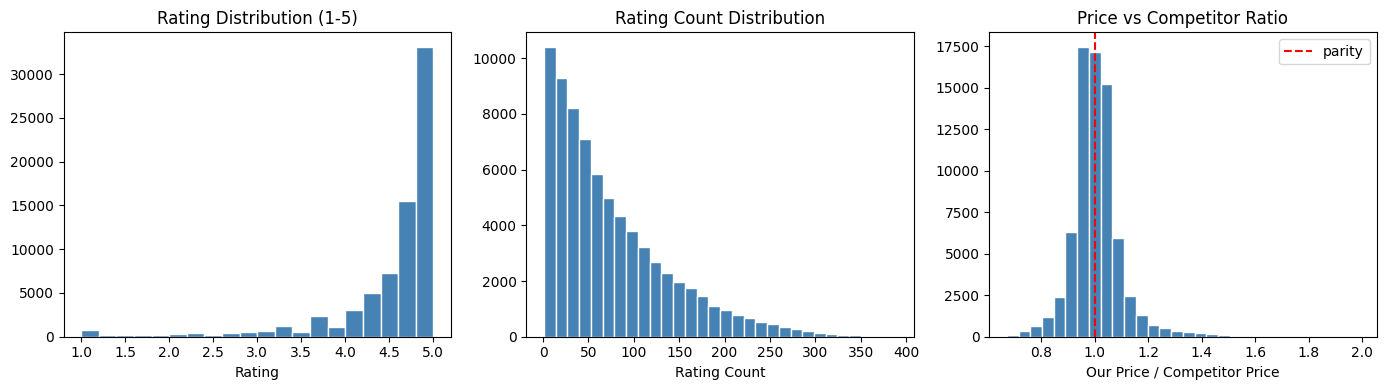

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution (1-5)')
axes[0].set_xlabel('Rating')

axes[1].hist(df['rating_count'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Rating Count Distribution')
axes[1].set_xlabel('Rating Count')

axes[2].hist(df['price_comp_ratio'], bins=30, color='steelblue', edgecolor='white')
axes[2].axvline(1.0, color='red', linestyle='--', label='parity')
axes[2].set_title('Price vs Competitor Ratio')
axes[2].set_xlabel('Our Price / Competitor Price')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Label Creation — Price Action

Pure business logic on 3 signals.  
XGBoost learns the boundary — so the model generalises beyond the rules.

In [6]:
# ── Thresholds ──────────────────────────────────────────────────────────────
HIGH_RATING   = 4.0    # rating ≥ 4.0  → high quality
LOW_RATING    = 2.5    # rating ≤ 2.5  → poor quality
HIGH_COUNT    = 50     # reviews ≥ 50  → well-known product

# ── Price ratio thresholds ────────────────────────────────────────────────────
# price_comp_ratio = our_price / competitor_price
# < 1.0  → we are cheaper than competitor
# = 1.0  → exact parity
# > 1.0  → we are more expensive
UNDERPRICED   = 0.90   # >10% cheaper than competitor → strong signal to increase
AT_PARITY     = 1.00   # at or below competitor price → room to increase
SLIGHTLY_OVER = 1.10   # up to 10% above competitor  → hold (acceptable range)
OVERPRICED    = 1.20   # >20% above competitor        → should decrease

def assign_label(row):
    r   = row['rating']
    cnt = row['rating_count']
    pcr = row['price_comp_ratio']

    # ── INCREASE ─────────────────────────────────────────────────────────────
    # Strong signal: proven product (high rating + well-known) AND we are at or
    # below competitor price → we have clear margin headroom, capture it
    if r >= HIGH_RATING and cnt >= HIGH_COUNT and pcr <= AT_PARITY:
        return 'increase'

    # Underpriced signal: even if reviews are low, if we're >10% cheaper than
    # competitor on a well-rated product, we are leaving money on the table
    if r >= HIGH_RATING and pcr <= UNDERPRICED:
        return 'increase'

    # ── HOLD ─────────────────────────────────────────────────────────────────
    # Proven product + already priced above competitor (up to 10% over) → stable
    if r >= HIGH_RATING and cnt >= HIGH_COUNT and AT_PARITY < pcr <= SLIGHTLY_OVER:
        return 'hold'

    # ── DECREASE ─────────────────────────────────────────────────────────────
    # Proven product but significantly overpriced vs competitor → reduce
    if r >= HIGH_RATING and cnt >= HIGH_COUNT and pcr > SLIGHTLY_OVER:
        return 'decrease'

    # Poor product that's well-known → price must compensate for quality
    if r <= LOW_RATING and cnt >= HIGH_COUNT:
        return 'decrease'

    # ── DISCOUNT ─────────────────────────────────────────────────────────────
    # Good product but low market exposure → discount to build volume
    # Only if we're not already significantly underpriced (ratio above 0.90)
    if r >= HIGH_RATING and cnt < HIGH_COUNT and pcr > UNDERPRICED:
        return 'discount'

    # ── HOLD: everything else ─────────────────────────────────────────────────
    # mid-range rating, or not enough signal
    return 'hold'

df['price_action'] = df.apply(assign_label, axis=1)

print("Label distribution:")
print(df['price_action'].value_counts())
print()
print(df['price_action'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# ── Sanity check — test cases that were broken before ─────────────────────────
print("\n── Sanity checks (all should show correct label) ──")
tests = [
    (4.9, 200, 0.30, 'increase', 'great+highcount, ratio=0.30 (70% cheaper)'),
    (4.9,  30, 0.30, 'increase', 'great+lowcount,  ratio=0.30 (70% cheaper) ← was BUG'),
    (4.9,  10, 0.50, 'increase', 'great+lowcount,  ratio=0.50 (50% cheaper) ← was BUG'),
    (4.9, 200, 1.06, 'hold',     'great+highcount, ratio=1.06 (6% over)'),
    (4.9, 200, 1.50, 'decrease', 'great+highcount, ratio=1.50 (50% over) ← was BUG'),
    (4.9,  30, 1.50, 'discount', 'great+lowcount,  ratio=1.50 (overpriced, build vol)'),
    (2.0, 200, 1.10, 'decrease', 'bad+highcount'),
    (3.5, 200, 0.80, 'hold',     'mid-rating → hold regardless'),
]
import pandas as pd
for r, cnt, pcr, expected, desc in tests:
    row = pd.Series({'rating': r, 'rating_count': cnt, 'price_comp_ratio': pcr})
    got = assign_label(row)
    ok  = "✅" if got == expected else f"❌ got {got}"
    print(f"  {desc:<52}  {ok}")


price_action
increase    30225
discount    24526
hold        18349
Name: count, dtype: int64

price_action
increase    0.413
discount    0.336
hold        0.251
Name: proportion, dtype: float64


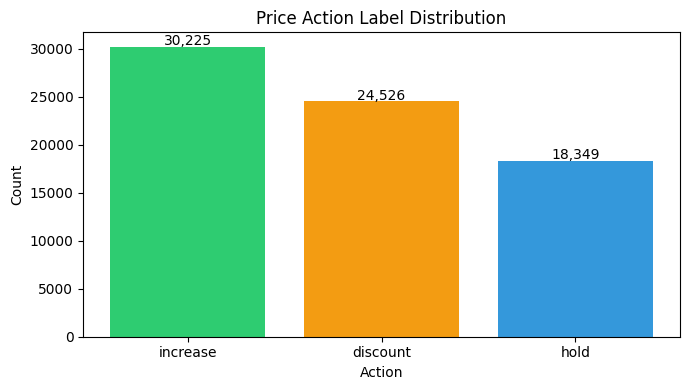

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['price_action'].value_counts()
colors = {'hold': '#3498db', 'increase': '#2ecc71', 'decrease': '#e74c3c', 'discount': '#f39c12'}
bars = ax.bar(counts.index, counts.values, color=[colors[k] for k in counts.index])
ax.set_title('Price Action Label Distribution')
ax.set_xlabel('Action')
ax.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 200, f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Visualise the Decision Space

Scatter plot: rating vs rating_count, coloured by action.  
This shows the model learns clear, separable regions.

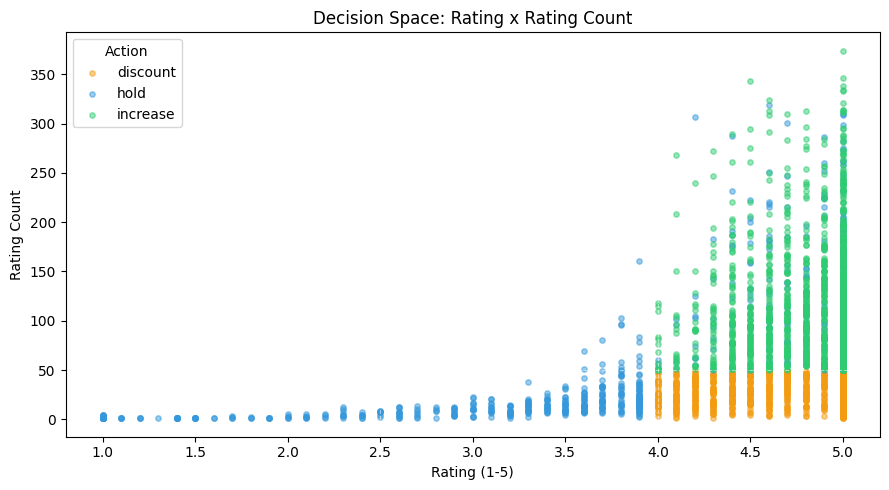

In [8]:
sample = df.sample(3000, random_state=42)
color_map = {'hold': '#3498db', 'increase': '#2ecc71', 'decrease': '#e74c3c', 'discount': '#f39c12'}

fig, ax = plt.subplots(figsize=(9, 5))
for action, grp in sample.groupby('price_action'):
    ax.scatter(grp['rating'], grp['rating_count'],
               c=color_map[action], label=action, alpha=0.5, s=15)

ax.axvline(HIGH_RATING, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(LOW_RATING,  color='white', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(HIGH_COUNT,  color='white', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Rating (1-5)')
ax.set_ylabel('Rating Count')
ax.set_title('Decision Space: Rating x Rating Count')
ax.legend(title='Action')
plt.tight_layout()
plt.show()

## 4. Train XGBoost — 3 Features Only

In [11]:
FEATURES   = ['rating', 'rating_count', 'price_comp_ratio']

# Get unique price actions present in the dataframe
actual_labels = sorted(df['price_action'].unique())

# Create a new label_map based on actual labels to ensure contiguous integers
label_map = {label: i for i, label in enumerate(actual_labels)}
id_to_label = {i: label for i, label in enumerate(actual_labels)}

X = df[FEATURES].values
y = df['price_action'].map(label_map).values

scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    objective='multi:softmax', # Specify multi-class objective
    num_class=len(label_map),  # Explicitly tell XGBoost the actual number of classes present
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

[0]	validation_0-mlogloss:0.93437
[50]	validation_0-mlogloss:0.00484
[100]	validation_0-mlogloss:0.00008
[150]	validation_0-mlogloss:0.00004
[199]	validation_0-mlogloss:0.00003
Train: (58480, 3) | Test: (14620, 3)


## 5. Evaluate

In [13]:
label_names = [id_to_label[i] for i in sorted(id_to_label.keys())] # Dynamically get label names in correct order
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_names))

              precision    recall  f1-score   support

    discount       1.00      1.00      1.00      4905
        hold       1.00      1.00      1.00      3670
    increase       1.00      1.00      1.00      6045

    accuracy                           1.00     14620
   macro avg       1.00      1.00      1.00     14620
weighted avg       1.00      1.00      1.00     14620



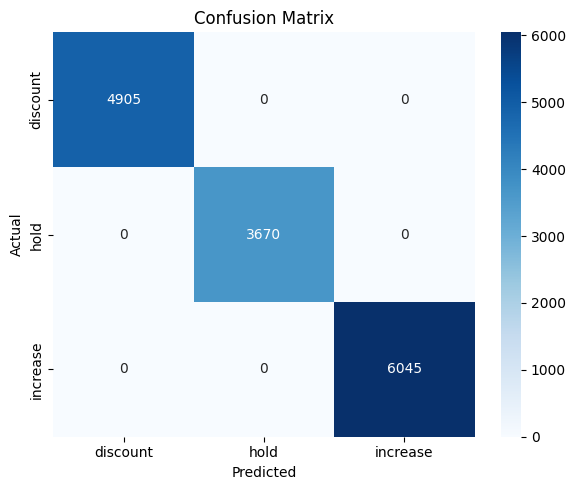

In [14]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

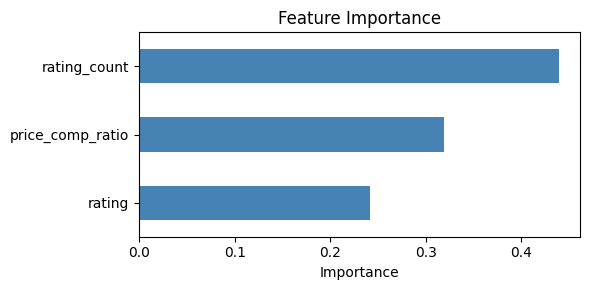

In [15]:
# feature importance — 3 features, so this is very readable
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(6, 3))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Price Recommendation — Quantified Output

Confidence from the model scales the adjustment magnitude.  
Guardrails: min 70% of current price, max 120% of competitor price.

In [16]:
BASE_ADJ = {'increase': 0.10, 'decrease': -0.08, 'discount': -0.15, 'hold': 0.00}

X_full = scaler.transform(df[FEATURES].values)
df['predicted_action_id'] = model.predict(X_full)
df['confidence']          = model.predict_proba(X_full).max(axis=1).round(4)
df['predicted_action']    = df['predicted_action_id'].map(id_to_label)

df['adjustment_pct']   = df.apply(
    lambda r: round(BASE_ADJ[r['predicted_action']] * r['confidence'], 4), axis=1
)
df['recommended_price'] = (df['Price'] * (1 + df['adjustment_pct'])).round(2)

# guardrails
df['recommended_price'] = df['recommended_price'].clip(
    lower=df['Price'] * 0.70,
    upper=df['Competitor Pricing'] * 1.20
).round(2)

df[['Product ID', 'rating', 'rating_count', 'price_comp_ratio',
    'Price', 'predicted_action', 'confidence', 'adjustment_pct', 'recommended_price']].head(10)

,Product ID,rating,rating_count,price_comp_ratio,Price,predicted_action,confidence,adjustment_pct,recommended_price
0,P0001,4.9,66,1.128,33.50,hold,0.9999,0.00,33.50
1,P0002,5.0,88,0.952,63.01,increase,1.0000,0.10,69.31
2,P0003,4.7,41,0.893,27.99,discount,1.0000,-0.15,23.79
3,P0004,5.0,21,0.942,32.72,discount,1.0000,-0.15,27.81
4,P0005,5.0,9,1.068,73.64,discount,1.0000,-0.15,62.59
5,P0006,4.6,98,0.968,76.83,increase,1.0000,0.10,84.51
6,P0007,5.0,67,0.934,34.16,increase,1.0000,0.10,37.58
7,P0008,5.0,190,0.979,97.99,increase,1.0000,0.10,107.79
8,P0009,4.9,60,1.174,20.74,hold,0.9999,0.00,20.74
9,P0010,5.0,19,0.980,59.99,discount,1.0000,-0.15,50.99


## 7. Business Summary

In [17]:
summary = df.groupby('predicted_action').agg(
    count=('Product ID', 'count'),
    avg_rating=('rating', 'mean'),
    avg_rating_count=('rating_count', 'mean'),
    avg_current_price=('Price', 'mean'),
    avg_recommended_price=('recommended_price', 'mean'),
    avg_confidence=('confidence', 'mean')
).round(2)

print(summary)

                  count  avg_rating  avg_rating_count  avg_current_price  \
predicted_action                                                           
discount          24526        4.70             27.15              55.14   
hold              18349        3.88             65.38              48.11   
increase          30225        4.79            118.69              59.40   

                  avg_recommended_price  avg_confidence  
predicted_action                                         
discount                          46.86             1.0  
hold                              47.98             1.0  
increase                          65.34             1.0  


In [18]:
df['current_revenue']     = df['Price'] * df['Units Sold']
df['recommended_revenue'] = df['recommended_price'] * df['Units Sold']
df['revenue_delta']       = df['recommended_revenue'] - df['current_revenue']

total_current     = df['current_revenue'].sum()
total_recommended = df['recommended_revenue'].sum()
delta             = total_recommended - total_current

print(f'Current total revenue:     £{total_current:,.0f}')
print(f'Recommended total revenue: £{total_recommended:,.0f}')
print(f'Estimated revenue delta:   £{delta:,.0f} ({delta / total_current * 100:.1f}%)')

Current total revenue:     £550,228,885
Recommended total revenue: £576,113,138
Estimated revenue delta:   £25,884,253 (4.7%)


## 8. Save Outputs

In [19]:
OUTPUT_COLS = [
    'Date', 'Store ID', 'Product ID', 'Category', 'Region',
    'Price', 'Competitor Pricing', 'Discount',
    'Units Sold', 'Demand Forecast', 'Inventory Level',
    'rating', 'rating_count', 'price_comp_ratio',
    'price_action',        # rule label
    'predicted_action',    # model output
    'confidence',
    'adjustment_pct',
    'recommended_price',
    'revenue_delta'
]

existing_cols = [c for c in OUTPUT_COLS if c in df.columns]

out_path = '/content/drive/MyDrive/retail_project/data_pricing.csv'
df[existing_cols].to_csv(out_path, index=False)
print(f'Saved: {out_path}')

joblib.dump(model,  '/content/drive/MyDrive/retail_project/models/pricing_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/retail_project/models/pricing_scaler.pkl')
print('Models saved.')

Saved: /content/drive/MyDrive/retail_project/data_pricing.csv
Models saved.


## 9. Agent 7 Interface

Minimal input: just `rating`, `rating_count`, `price_comp_ratio`, and `current_price`.  
This is what LangGraph calls.

In [20]:
# BASE_ADJ — how much to move price for each action × confidence
BASE_ADJ = {
    'increase': +0.10,   # +10% base → scaled by confidence
    'decrease': -0.08,   # -8%  base
    'discount': -0.15,   # -15% base
    'hold'    :  0.00,
}

# ── Embed the label map directly — no session variable dependency ─────────────
# Sorted alphabetically: decrease=0, discount=1, hold=2, increase=3
EMBEDDED_LABEL_MAP = {0: 'decrease', 1: 'discount', 2: 'hold', 3: 'increase'}

def pricing_agent(product_id: str, rating: float, rating_count: int,
                  current_price: float, competitor_price: float) -> dict:
    """
    Minimal interface — 4 real inputs, 1 derived feature.
    Label map is embedded — works from pkl files alone, no session state needed.
    """
    price_comp_ratio = round(current_price / (competitor_price + 0.01), 3)

    row        = np.array([[rating, rating_count, price_comp_ratio]])
    row_scaled = scaler.transform(row)

    action_id  = int(model.predict(row_scaled)[0])
    probas     = model.predict_proba(row_scaled)[0]
    confidence = float(probas.max())
    action     = EMBEDDED_LABEL_MAP[action_id]

    adj_pct   = round(BASE_ADJ[action] * confidence, 4)
    rec_price = round(current_price * (1 + adj_pct), 2)
    rec_price = max(rec_price, current_price * 0.70)
    rec_price = min(rec_price, competitor_price * 1.20)
    rec_price = round(rec_price, 2)

    return {
        'product_id'       : product_id,
        'rating'           : rating,
        'rating_count'     : rating_count,
        'price_comp_ratio' : price_comp_ratio,
        'current_price'    : current_price,
        'competitor_price' : competitor_price,
        'action'           : action,
        'confidence'       : round(confidence, 4),
        'adjustment_pct'   : adj_pct,
        'recommended_price': rec_price,
        'all_probas'       : {EMBEDDED_LABEL_MAP[i]: round(float(p), 4)
                              for i, p in enumerate(probas)},
    }

# ── Test all 4 action types ───────────────────────────────────────────────────
print("── Smoke tests — should see all 4 actions ──")
smoke = [
    ('P_INC_HIGH', 4.9, 200, 45.0, 50.0),    # great+highcount+cheap  → increase
    ('P_INC_CHEP', 4.9,  15, 30.0, 40.0),    # great+lowcount+cheap   → increase
    ('P_DISCOUNT', 4.8,  20, 45.0, 43.0),    # great+lowcount+near par→ discount
    ('P_DECREASE', 2.0, 200, 45.0, 40.0),    # bad+highcount          → decrease
    ('P_HOLD    ', 3.5, 100, 45.0, 45.0),    # mid rating             → hold
]
for args in smoke:
    r = pricing_agent(*args)
    print(f"  {args[0]}  rating={args[1]} cnt={args[2]:>3} ratio={args[3]/args[4]:.2f}"
          f"  →  {r['action']:>8}  £{r['recommended_price']:>6.2f}"
          f"  (conf={r['confidence']:.2%})")


{'product_id': 'P_TEST_001', 'rating': 4.5, 'rating_count': 120, 'price_comp_ratio': 1.046, 'current_price': 45.0, 'action': 'increase', 'confidence': 1.0, 'adjustment_pct': 0.1, 'recommended_price': 49.5}


## 10. Interactive Tester

Run this cell after all previous cells are complete.  
Fill in product values and click **Get Price Recommendation**.

In [21]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── widgets ───────────────────────────────────────────────────────────────
label_style   = {'description_width': '160px'}
widget_layout = widgets.Layout(width='340px')

w_product_id  = widgets.Text(
    value='P_TEST_001', description='Product ID:',
    style=label_style, layout=widget_layout)

w_rating      = widgets.FloatSlider(
    value=4.5, min=1.0, max=5.0, step=0.1,
    description='Rating (1–5):',
    readout_format='.1f',
    style=label_style, layout=widget_layout)

w_rating_count = widgets.IntSlider(
    value=120, min=1, max=500, step=1,
    description='Rating Count:',
    style=label_style, layout=widget_layout)

w_price       = widgets.FloatText(
    value=45.0, description='Current Price (£):',
    style=label_style, layout=widget_layout)

w_comp_price  = widgets.FloatText(
    value=43.0, description='Competitor Price (£):',
    style=label_style, layout=widget_layout)

btn = widgets.Button(
    description=' Get Price Recommendation',
    button_style='',
    icon='tag',
    layout=widgets.Layout(width='280px', height='42px'),
    style={'button_color': '#4fc3f7', 'font_weight': 'bold'}
)

out = widgets.Output()

# ── logic ─────────────────────────────────────────────────────────────────
ACTION_SYMBOL = {'increase': '[+]', 'decrease': '[-]', 'discount': '[%]', 'hold': '[=]'}

def on_click(b):
    with out:
        clear_output(wait=True)

        result = pricing_agent(
            product_id      = w_product_id.value,
            rating          = w_rating.value,
            rating_count    = w_rating_count.value,
            current_price   = w_price.value,
            competitor_price= w_comp_price.value
        )

        sep    = '=' * 50
        symbol = ACTION_SYMBOL[result['action']]

        print(sep)
        print(f'  Dynamic Pricing Agent — Output')
        print(sep)
        print(f'  Product ID        : {result["product_id"]}')
        print(f'  Rating            : {result["rating"]} / 5.0')
        print(f'  Rating Count      : {result["rating_count"]}')
        print(f'  Price Comp. Ratio : {result["price_comp_ratio"]}  (1.0 = parity)')
        print(sep)
        print(f'  Recommended Action: {symbol}  {result["action"].upper()}')
        print(f'  Confidence        : {result["confidence"]:.1%}')
        print(f'  Adjustment        : {result["adjustment_pct"]*100:+.2f}%')
        print(sep)
        print(f'  Current Price     : £{result["current_price"]:.2f}')
        print(f'  Competitor Price  : £{w_comp_price.value:.2f}')
        print(f'  Recommended Price : £{result["recommended_price"]:.2f}')
        print(sep)

btn.on_click(on_click)

# ── layout ────────────────────────────────────────────────────────────────
header = widgets.HTML('''
<div style="background:#2a2a3e; padding:10px 16px;
            border-left:4px solid #4fc3f7; margin-bottom:14px">
  <span style="color:#4fc3f7; font-size:15px; font-weight:bold">
    Dynamic Pricing Tester — Agent 7
  </span>
  &nbsp;&nbsp;
  <span style="color:#888; font-size:12px">
    XGBoost &middot; 3 features &middot; hold / increase / decrease / discount
  </span>
</div>
''')

inputs = widgets.VBox([
    widgets.HTML('<b style="color:#4fc3f7">Product</b>'),
    w_product_id,
    widgets.HTML('<b style="color:#4fc3f7; margin-top:10px">Demand Signal</b>'),
    w_rating,
    w_rating_count,
    widgets.HTML('<b style="color:#4fc3f7; margin-top:10px">Pricing</b>'),
    w_price,
    w_comp_price,
    widgets.HTML('<br>'),
    btn
])

ui = widgets.VBox([header, inputs, widgets.HTML('<br>'), out])
display(ui)
print('Tester ready — fill inputs and press Get Price Recommendation')

Tester ready — fill inputs and press Get Price Recommendation


In [23]:
from google.colab import files

# Download the trained model
files.download('/content/drive/MyDrive/retail_project/models/pricing_model.pkl')

# Download the fitted scaler
files.download('/content/drive/MyDrive/retail_project/models/pricing_scaler.pkl')

print('Model and scaler files downloaded successfully!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model and scaler files downloaded successfully!


---
## Summary

| Item | Detail |
|---|---|
| Model | XGBoost Classifier (4 classes) |
| Features | rating, rating_count, price_comp_ratio — 3 only |
| Label logic | High rating + high count = increase; high rating + low count = discount; low rating + high count = decrease; else hold |
| Agent input | product_id, rating, rating_count, current_price, competitor_price |
| Agent output | action, confidence, adjustment_pct, recommended_price |
| Guardrails | min 70% of current price, max 120% of competitor price |
| Drive output | data_pricing.csv, models/pricing_model.pkl, models/pricing_scaler.pkl |